# Quantum Computing Basics with PennyLane

Going through the basic ideas - qubits, superposition, gates, measurement and entanglement -
and building each one as a circuit in PennyLane.

## 1. Setup

In [1]:
!pip install pennylane --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# the device is what the circuit runs on
dev1 = qml.device("default.qubit", wires=1)
dev2 = qml.device("default.qubit", wires=2)

## 2. Qubit states

A qubit starts in the state |0⟩. `qml.state()` returns the state vector, which is the
amplitude of |0⟩ followed by the amplitude of |1⟩.

The `@qml.qnode(dev)` decorator is what turns a normal function into a quantum circuit.

In [4]:
@qml.qnode(dev1)
def ground_state():
    return qml.state()

print(ground_state())   # [1, 0] means it is definitely |0>

[1.+0.j 0.+0.j]


## 3. Superposition

The Hadamard gate puts the qubit into an equal superposition of |0⟩ and |1⟩.
Both amplitudes become 1/sqrt(2) = 0.7071.

Probabilities are the amplitudes squared, so this gives 50/50.

In [5]:
@qml.qnode(dev1)
def superposition():
    qml.Hadamard(wires=0)
    return qml.state()

print(superposition())

[0.70710678+0.j 0.70710678+0.j]


In [6]:
@qml.qnode(dev1)
def superposition_probs():
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

print(superposition_probs())

[0.5 0.5]


## 4. Single qubit gates

- **PauliX** is the quantum NOT gate, it flips |0⟩ to |1⟩
- **PauliZ** flips the sign of the |1⟩ amplitude

In [7]:
@qml.qnode(dev1)
def flip():
    qml.PauliX(wires=0)
    return qml.probs(wires=0)

print(flip())   # [0, 1], the qubit is now |1>

[0. 1.]


In [8]:
# gates run in the order they are written
@qml.qnode(dev1)
def h_then_z():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    return qml.state()

print("state:", h_then_z())

state: [ 0.70710678+0.j -0.70710678+0.j]


The second amplitude is now negative. The probabilities are still 50/50 because squaring
removes the sign, but that sign (the phase) still matters - it changes what happens if we
apply more gates after it.

## 5. Rotation gates

Gates can take an angle as a parameter. `RX` rotates the qubit by theta, so we can get any
mix between |0⟩ and |1⟩ instead of just 0, 1 or 50/50. This is what variational / quantum
machine learning circuits are built out of.

In [9]:
@qml.qnode(dev1)
def rx_circuit(theta):
    qml.RX(theta, wires=0)
    return qml.probs(wires=0)

for theta in [0, np.pi / 2, np.pi]:
    print("theta =", round(theta, 3), "->", rx_circuit(theta))

theta = 0 -> [1. 0.]
theta = 1.571 -> [0.5 0.5]
theta = 3.142 -> [3.74939946e-33 1.00000000e+00]


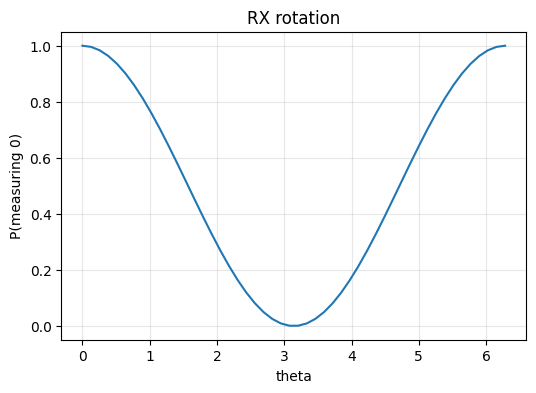

In [10]:
angles = np.linspace(0, 2 * np.pi, 50)
prob_zero = [rx_circuit(t)[0] for t in angles]

plt.figure(figsize=(6, 4))
plt.plot(angles, prob_zero)
plt.xlabel("theta")
plt.ylabel("P(measuring 0)")
plt.title("RX rotation")
plt.grid(alpha=0.3)
plt.show()

## 6. Measurement

The probabilities above are exact because it is a simulator. 

In [13]:
dev1_shots = qml.device("default.qubit", wires=1, shots=1000)

@qml.qnode(dev1_shots)
def measure_shots():
    qml.Hadamard(wires=0)
    return qml.counts()

print(measure_shots())   # close to 500/500 but never exactly

{np.str_('0'): np.int64(500), np.str_('1'): np.int64(500)}


In [14]:
# expectation value: +1 if the qubit is |0>, -1 if it is |1>, 0 for an even superposition
@qml.qnode(dev1)
def expectation():
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

print(expectation())

0.0


## 7. Entanglement

Hadamard on the first qubit, then CNOT (flips the second qubit only if the first one is 1).
This gives the Bell state, where the two qubits are entangled - the outcomes are always
the same, even though each qubit on its own is still random.

In [15]:
@qml.qnode(dev2)
def bell_state():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

print(bell_state())   # order is [00, 01, 10, 11]

[0.5 0.  0.  0.5]


In [16]:
dev2_shots = qml.device("default.qubit", wires=2, shots=1000)

@qml.qnode(dev2_shots)
def bell_counts():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.counts()

print(bell_counts())   # only 00 and 11 ever show up

{np.str_('00'): np.int64(515), np.str_('11'): np.int64(485)}


In [17]:
# for comparison: a Hadamard on each qubit is random too, but NOT entangled
@qml.qnode(dev2)
def both_hadamard():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.probs(wires=[0, 1])

print(both_hadamard())   # all four outcomes happen, so the qubits are independent

[0.25 0.25 0.25 0.25]


That is the difference. Both circuits are random, but in the entangled one measuring the first
qubit instantly tells you the second one. In the second circuit it tells you nothing.

## 8. Circuit diagrams

`qml.draw` prints the circuit so you can check the gates are where you think they are.

In [18]:
print(qml.draw(bell_state)())
print()
print(qml.draw(rx_circuit)(np.pi / 2))

0: ──H─╭●─┤ ╭Probs
1: ────╰X─┤ ╰Probs

0: ──RX(1.57)─┤  Probs
